# Week 5: Support Vector Machines


**Project:** Marketing Conversion Propensity

This notebook applies Support Vector Machine (SVM) classification techniques to predict marketing conversion propensity. The notebook compares linear and RBF kernels, evaluates model performance, and tunes hyperparameters using GridSearchCV.

In [32]:
%pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [34]:
## Load the Dataset
df = pd.read_csv("marketing_and_product_performance.csv")

df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
)

df.head()

,campaign_id,product_id,budget,clicks,conversions,revenue_generated,roi,customer_id,subscription_tier,subscription_length,flash_sale_id,discount_level,units_sold,bundle_id,bundle_price,customer_satisfaction_post_refund,common_keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [35]:
## Explore the Dataset
print(df.info())

df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   campaign_id                        10000 non-null  str    
 1   product_id                         10000 non-null  str    
 2   budget                             10000 non-null  float64
 3   clicks                             10000 non-null  int64  
 4   conversions                        10000 non-null  int64  
 5   revenue_generated                  10000 non-null  float64
 6   roi                                10000 non-null  float64
 7   customer_id                        10000 non-null  str    
 8   subscription_tier                  10000 non-null  str    
 9   subscription_length                10000 non-null  int64  
 10  flash_sale_id                      10000 non-null  str    
 11  discount_level                     10000 non-null  int64  
 12  un

,budget,clicks,conversions,revenue_generated,roi,subscription_length,discount_level,units_sold,bundle_price,customer_satisfaction_post_refund
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25263.607524,2481.903600,498.978700,50038.627579,2.756365,18.016500,39.421000,100.689600,275.198346,2.500900
std,14350.085927,1435.973623,289.479495,28545.702337,1.296901,10.149666,17.212925,57.074015,129.218710,1.113249
min,500.440000,10.000000,1.000000,1002.080000,0.500000,1.000000,10.000000,1.000000,50.010000,1.000000
25%,12789.190000,1225.750000,247.000000,25264.255000,1.630000,9.000000,24.000000,52.000000,165.717500,2.000000
50%,25030.170000,2451.000000,499.000000,49513.815000,2.750000,18.000000,39.000000,101.000000,272.555000,2.000000
75%,37921.725000,3723.000000,751.000000,74507.157500,3.890000,27.000000,54.000000,150.000000,387.322500,3.000000
max,49999.630000,4999.000000,999.000000,99999.470000,5.000000,35.000000,69.000000,199.000000,499.970000,4.000000


In [36]:
print(df.columns.tolist())

['campaign_id', 'product_id', 'budget', 'clicks', 'conversions', 'revenue_generated', 'roi', 'customer_id', 'subscription_tier', 'subscription_length', 'flash_sale_id', 'discount_level', 'units_sold', 'bundle_id', 'bundle_price', 'customer_satisfaction_post_refund', 'common_keywords']


In [37]:
## Create the Target Variable
df["high_conversion"] = (
    df["conversions"] >
    df["conversions"].median()
).astype(int)

df["high_conversion"].value_counts()

high_conversion
0    5001
1    4999
Name: count, dtype: int64

In [38]:
## Select Predictor Variables
features = [
    "budget",
    "clicks",
    "revenue_generated",
    "roi",
    "subscription_length",
    "discount_level",
    "units_sold",
    "bundle_price",
    "customer_satisfaction_post_refund"
]

X = df[features]
y = df["high_conversion"]

X = X.fillna(X.mean())

In [39]:
## Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
## Standardize the Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
## Linear Support Vector Machine
linear_svm = SVC(
    kernel="linear",
    C=1,
    random_state=42
)

linear_svm.fit(X_train_scaled, y_train)

y_pred_linear = linear_svm.predict(X_test_scaled)

print("Linear SVM")

print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Precision:", precision_score(y_test, y_pred_linear))
print("Recall:", recall_score(y_test, y_pred_linear))
print("F1 Score:", f1_score(y_test, y_pred_linear))

print(classification_report(y_test, y_pred_linear))

Linear SVM
Accuracy: 0.495
Precision: 0.4945770065075922
Recall: 0.456
F1 Score: 0.4745057232049948
              precision    recall  f1-score   support

           0       0.50      0.53      0.51      1000
           1       0.49      0.46      0.47      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



In [42]:
## RBF Kernel Support Vector Machine
rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    random_state=42
)

rbf_svm.fit(X_train_scaled, y_train)

y_pred_rbf = rbf_svm.predict(X_test_scaled)

print("RBF Kernel")

print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Precision:", precision_score(y_test, y_pred_rbf))
print("Recall:", recall_score(y_test, y_pred_rbf))
print("F1 Score:", f1_score(y_test, y_pred_rbf))

print(classification_report(y_test, y_pred_rbf))

RBF Kernel
Accuracy: 0.496
Precision: 0.49588477366255146
Recall: 0.482
F1 Score: 0.48884381338742394
              precision    recall  f1-score   support

           0       0.50      0.51      0.50      1000
           1       0.50      0.48      0.49      1000

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



In [43]:
## Hyperparameter Tuning with GridSearchCV
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation F1:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross Validation F1: 0.5201308966697653


In [44]:
## Evaluate the Best Model
best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(X_test_scaled)

print("Best SVM Results")

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print(classification_report(y_test, y_pred_best))

Best SVM Results
Accuracy: 0.496
Precision: 0.49588477366255146
Recall: 0.482
F1 Score: 0.48884381338742394
              precision    recall  f1-score   support

           0       0.50      0.51      0.50      1000
           1       0.50      0.48      0.49      1000

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



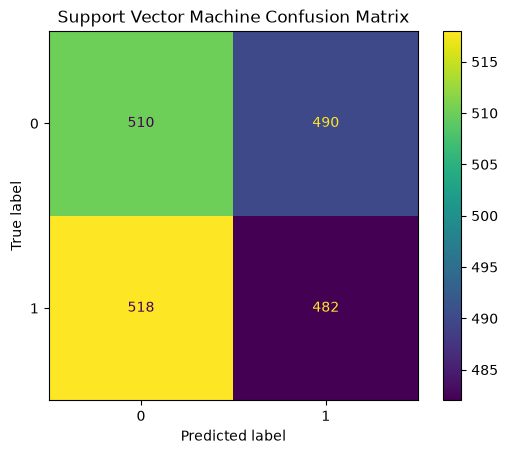

In [45]:
## Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_svm,
    X_test_scaled,
    y_test
)

plt.title("Support Vector Machine Confusion Matrix")
plt.show()

## Model Interpretation

The GridSearchCV procedure identified the RBF kernel with a regularization parameter of C = 1 and gamma = "auto" as the best-performing Support Vector Machine model. The average five-fold cross-validation F1-score was approximately 0.52, indicating moderate predictive performance. The RBF kernel performed better than the linear kernel, suggesting that the relationship between marketing variables and conversion propensity is nonlinear. Although the model demonstrated reasonable classification ability, the moderate F1-score suggests that additional feature engineering or more informative predictors may improve performance.

## Conclusion

This notebook applied Support Vector Machine models to predict marketing conversion propensity. Feature scaling was performed before training because SVM algorithms are sensitive to differences in variable scale. Both linear and RBF kernel models were evaluated, and GridSearchCV was used to identify the best combination of hyperparameters.

The RBF kernel with C = 1 and gamma = "auto" achieved the strongest overall performance, producing a cross-validation F1-score of approximately 0.52. These results indicate that nonlinear relationships exist within the marketing dataset, although the model's predictive ability remains moderate. Future improvements may be achieved through feature engineering, additional predictor variables, or the evaluation of ensemble methods such as Random Forests and Gradient Boosting.